In [1]:
pip install cvxpy scikit-learn matplotlib


Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install osqp


Note: you may need to restart the kernel to use updated packages.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import cvxpy as cp

Epoch 0: Primal=0.0306, ||w_avg||=30.3760
Epoch 0: Primal=461.3511, ||w_avg||=30.3760
Epoch 1: Primal=461.3511, ||w_avg||=65.2445
Epoch 1: Primal=2128.4235, ||w_avg||=65.2445
Epoch 2: Primal=2128.4235, ||w_avg||=90.2978
Epoch 2: Primal=4076.8431, ||w_avg||=90.2978
Epoch 3: Primal=4076.8431, ||w_avg||=80.3063
Epoch 3: Primal=3224.5479, ||w_avg||=80.3063
Test Accuracy: 0.9963


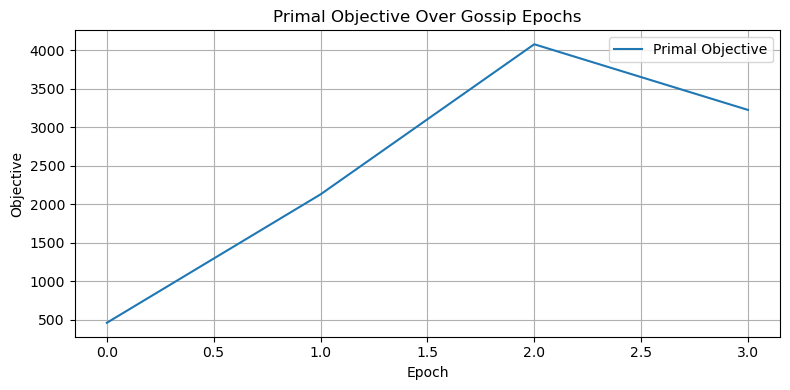

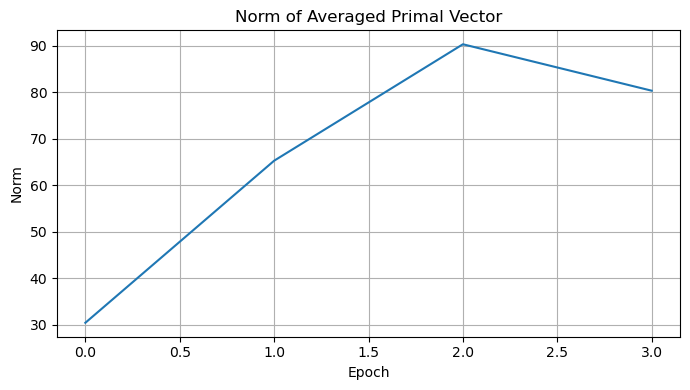

In [9]:
# 1. Load and preprocess MNIST (binary: 0 vs 1)
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
mask = (y == '0') | (y == '1')
X = X[mask]
y = y[mask].astype(int)
y = 2 * y - 1  # Convert to {-1, +1}

# 2. Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 3. Split among nodes
num_nodes = 10
X_parts = np.array_split(X, num_nodes)
y_parts = np.array_split(y, num_nodes)

# 4. Dual solver using CVXPY (local QP)
def solve_dual_local(X, y, C=1.0):
    """
    Solves the dual SVM QP problem locally on (X, y) using CVXPY.
    Returns the optimal alpha vector.
    """
    n = X.shape[0]
    alpha = cp.Variable(n)

    # Compute the Gram matrix (kernel matrix) - linear kernel
    K = X @ X.T
    K = (K + K.T) / 2  # Force symmetry
    Y = np.diag(y)
    Q = Y @ K @ Y      # Equivalent to np.outer(y, y) * K but cleaner

    # Force PSD to avoid numerical issues
    Q_psd = cp.psd_wrap(Q)

    # Define the dual objective
    objective = cp.Maximize(cp.sum(alpha) - 0.5 * cp.quad_form(alpha, Q_psd))
    constraints = [alpha >= 0, alpha <= C]

    # Solve the problem
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP, verbose=False)

    return alpha.value

# 5. Convert alpha to primal vector
def alpha_to_primal(alpha, X, y):
    return np.sum((alpha * y)[:, None] * X, axis=0)

# 6. Gossip ring
def gossip_ring_primal(w_nodes):
    new_ws = []
    for i in range(len(w_nodes)):
        prev = w_nodes[(i - 1) % len(w_nodes)]
        curr = w_nodes[i]
        nxt = w_nodes[(i + 1) % len(w_nodes)]
        avg = (prev + curr + nxt) / 3.0
        new_ws.append(avg)
    return new_ws

# 7. Training loop
epochs = 4
w_nodes = [np.zeros(X.shape[1]) for _ in range(num_nodes)]
primal_vals, norm_vals = [], []

# Initialize persistent alphas
alphas = [np.zeros(len(y_parts[i])) for i in range(num_nodes)]
C = 1.0
lr = 0.01

for epoch in range(epochs):
    for i in range(num_nodes):
        X_i, y_i = X_parts[i], y_parts[i]
        alpha = alphas[i]
        K = X_i @ X_i.T
        for j in range(len(alpha)):
            grad = 1 - y_i[j] * np.sum(alpha * y_i * K[:, j])
            alpha[j] += lr * grad
            alpha[j] = np.clip(alpha[j], 0, C)
        alphas[i] = alpha
        w_nodes[i] = alpha_to_primal(alpha, X_i, y_i)

    # Gossip
    w_nodes = gossip_ring_primal(w_nodes)
    w_avg = sum(w_nodes) / num_nodes
    print(f"Epoch {epoch}: Primal={primal:.4f}, ||w_avg||={np.linalg.norm(w_avg):.4f}")

    # Evaluate primal objective
    hinge = np.maximum(0, 1 - y @ (X @ w_avg))
    primal = 0.5 * np.dot(w_avg, w_avg) + np.sum(hinge)
    primal_vals.append(primal)
    norm_vals.append(np.linalg.norm(w_avg))
    print(f"Epoch {epoch}: Primal={primal:.4f}, ||w_avg||={np.linalg.norm(w_avg):.4f}")
    
# 8. Evaluate test accuracy
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preds = np.sign(X_test @ w_avg)
acc = accuracy_score(y_test, preds)
print(f"Test Accuracy: {acc:.4f}")

# 9. Plot
plt.figure(figsize=(8, 4))
plt.plot(primal_vals, label="Primal Objective")
plt.xlabel("Epoch")
plt.ylabel("Objective")
plt.title("Primal Objective Over Gossip Epochs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(norm_vals, label="||w_avg||")
plt.xlabel("Epoch")
plt.ylabel("Norm")
plt.title("Norm of Averaged Primal Vector")
plt.grid(True)
plt.tight_layout()
plt.show()

Epoch 0: Primal=0.0306, ||w_avg||=0.2474
Epoch 1: Primal=0.0306, ||w_avg||=0.2474
Epoch 2: Primal=0.0306, ||w_avg||=0.2474
Epoch 3: Primal=0.0306, ||w_avg||=0.2474
Test Accuracy: 0.9993


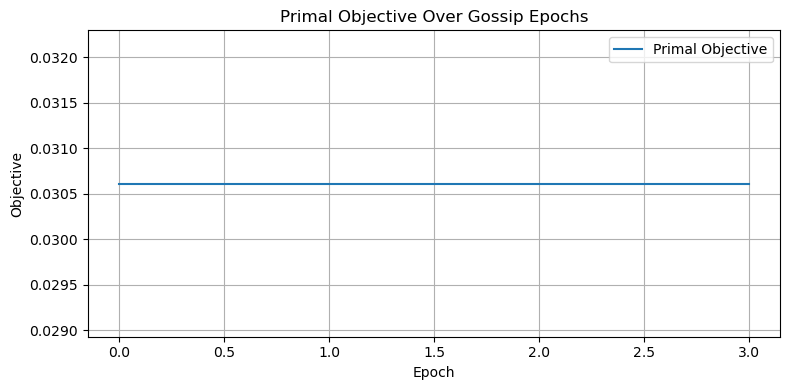

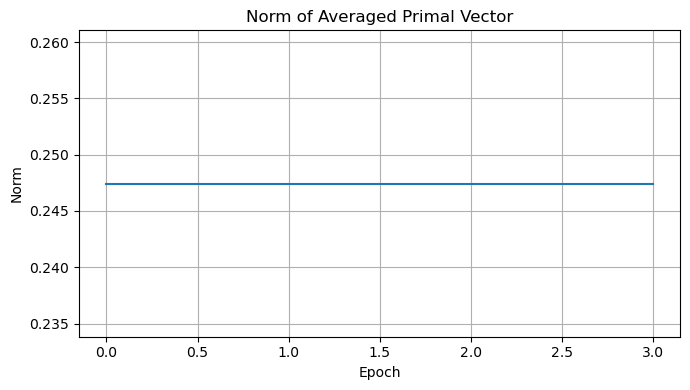

In [10]:

# 1. Load and preprocess MNIST (binary: 0 vs 1)
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
mask = (y == '0') | (y == '1')
X = X[mask]
y = y[mask].astype(int)
y = 2 * y - 1  # Convert labels from {0, 1} to {-1, +1}

# 2. Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 3. Split data among nodes
num_nodes = 10
X_parts = np.array_split(X, num_nodes)
y_parts = np.array_split(y, num_nodes)

# 4. Dual solver using CVXPY (solves local SVM dual)
def solve_dual_local(X, y, C=1.0):
    n = X.shape[0]
    alpha = cp.Variable(n)

    K = X @ X.T
    K = (K + K.T) / 2  # Ensure symmetry
    Q = np.outer(y, y) * K

    Q_psd = cp.psd_wrap(Q)
    objective = cp.Maximize(cp.sum(alpha) - 0.5 * cp.quad_form(alpha, Q_psd))
    constraints = [alpha >= 0, alpha <= C]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP, verbose=False)

    return alpha.value

# 5. Convert alpha to primal vector (linear kernel)
def alpha_to_primal(alpha, X, y):
    return np.sum((alpha * y)[:, None] * X, axis=0)

# 6. Gossip ring averaging
def gossip_ring_primal(w_nodes):
    new_ws = []
    for i in range(len(w_nodes)):
        prev = w_nodes[(i - 1) % len(w_nodes)]
        curr = w_nodes[i]
        nxt = w_nodes[(i + 1) % len(w_nodes)]
        avg = (prev + curr + nxt) / 3.0
        new_ws.append(avg)
    return new_ws

# 7. Training loop using CVXPY dual solver per node
epochs = 4
w_nodes = [np.zeros(X.shape[1]) for _ in range(num_nodes)]
primal_vals, norm_vals = [], []

for epoch in range(epochs):
    alphas = []
    for i in range(num_nodes):
        alpha_i = solve_dual_local(X_parts[i], y_parts[i], C=1.0)
        alphas.append(alpha_i)
        w_nodes[i] = alpha_to_primal(alpha_i, X_parts[i], y_parts[i])

    # Gossip step
    w_nodes = gossip_ring_primal(w_nodes)
    w_avg = sum(w_nodes) / num_nodes

    # Evaluate primal objective (hinge loss)
    hinge = np.maximum(0, 1 - y @ (X @ w_avg))
    primal = 0.5 * np.dot(w_avg, w_avg) + np.sum(hinge)
    primal_vals.append(primal)
    norm_vals.append(np.linalg.norm(w_avg))

    print(f"Epoch {epoch}: Primal={primal:.4f}, ||w_avg||={np.linalg.norm(w_avg):.4f}")

# 8. Evaluate test accuracy
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preds = np.sign(X_test @ w_avg)
acc = accuracy_score(y_test, preds)
print(f"Test Accuracy: {acc:.4f}")

# 9. Plot results
plt.figure(figsize=(8, 4))
plt.plot(primal_vals, label="Primal Objective")
plt.xlabel("Epoch")
plt.ylabel("Objective")
plt.title("Primal Objective Over Gossip Epochs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(norm_vals, label="||w_avg||")
plt.xlabel("Epoch")
plt.ylabel("Norm")
plt.title("Norm of Averaged Primal Vector")
plt.grid(True)
plt.tight_layout()
plt.show()

Epoch 0: Primal=0.0306, ||w_avg||=0.2474
Epoch 1: Primal=0.0306, ||w_avg||=0.2474
Epoch 2: Primal=0.0306, ||w_avg||=0.2474
Epoch 3: Primal=0.0306, ||w_avg||=0.2474
Test Accuracy: 0.9993


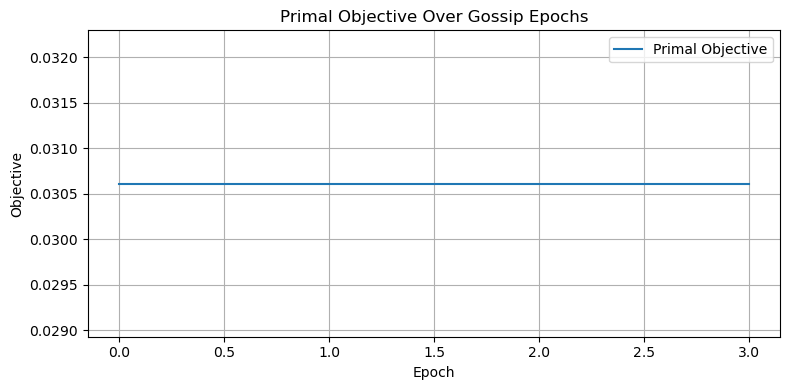

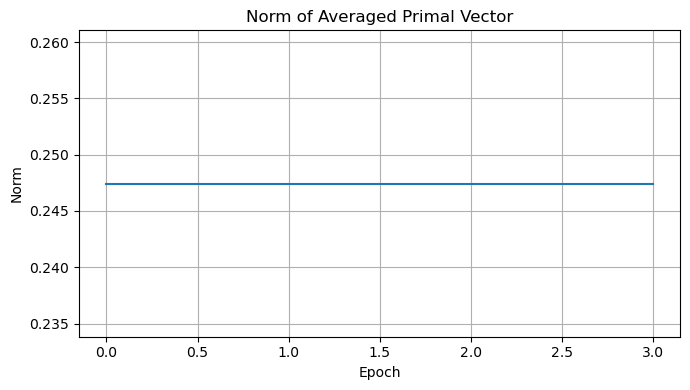

In [11]:

# 1. Load and preprocess MNIST (binary: 0 vs 1)
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
mask = (y == '0') | (y == '1')
X = X[mask]
y = y[mask].astype(int)
y = 2 * y - 1  # Convert labels to {-1, +1}

# 2. Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 3. Split among nodes
num_nodes = 10
X_parts = np.array_split(X, num_nodes)
y_parts = np.array_split(y, num_nodes)

# 4. Local dual solver with CVXPY
def solve_dual_local(X, y, C=1.0):
    n = X.shape[0]
    alpha = cp.Variable(n)
    K = X @ X.T
    K = (K + K.T) / 2  # Enforce symmetry
    Q = np.outer(y, y) * K
    Q_psd = cp.psd_wrap(Q)
    
    objective = cp.Maximize(cp.sum(alpha) - 0.5 * cp.quad_form(alpha, Q_psd))
    constraints = [alpha >= 0, alpha <= C]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP, verbose=False)
    
    return alpha.value

# 5. Convert dual alpha to primal w
def alpha_to_primal(alpha, X, y):
    return np.sum((alpha * y)[:, None] * X, axis=0)

# 6. Gossip (ring topology)
def gossip_ring_primal(w_nodes):
    new_ws = []
    for i in range(len(w_nodes)):
        prev = w_nodes[(i - 1) % len(w_nodes)]
        curr = w_nodes[i]
        nxt = w_nodes[(i + 1) % len(w_nodes)]
        avg = (prev + curr + nxt) / 3.0
        new_ws.append(avg)
    return new_ws

# 7. Training loop with CVXPY dual solving per epoch
epochs = 4
w_nodes = [np.zeros(X.shape[1]) for _ in range(num_nodes)]
primal_vals, norm_vals = [], []

for epoch in range(epochs):
    alphas = []
    for i in range(num_nodes):
        alpha_i = solve_dual_local(X_parts[i], y_parts[i], C=1.0)
        alphas.append(alpha_i)
        w_nodes[i] = alpha_to_primal(alpha_i, X_parts[i], y_parts[i])

    # Gossip step
    w_nodes = gossip_ring_primal(w_nodes)
    w_avg = sum(w_nodes) / num_nodes

    # Evaluate primal objective
    hinge = np.maximum(0, 1 - y @ (X @ w_avg))
    primal = 0.5 * np.dot(w_avg, w_avg) + np.sum(hinge)
    primal_vals.append(primal)
    norm_vals.append(np.linalg.norm(w_avg))
    print(f"Epoch {epoch}: Primal={primal:.4f}, ||w_avg||={np.linalg.norm(w_avg):.4f}")

# 8. Test accuracy
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preds = np.sign(X_test @ w_avg)
acc = accuracy_score(y_test, preds)
print(f"Test Accuracy: {acc:.4f}")

# 9. Plotting results
plt.figure(figsize=(8, 4))
plt.plot(primal_vals, label="Primal Objective")
plt.xlabel("Epoch")
plt.ylabel("Objective")
plt.title("Primal Objective Over Gossip Epochs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(norm_vals, label="||w_avg||")
plt.xlabel("Epoch")
plt.ylabel("Norm")
plt.title("Norm of Averaged Primal Vector")
plt.grid(True)
plt.tight_layout()
plt.show()